# Mount Google Drive dan Mengimpor Library yang Diperlukan

In [ ]:
#mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# memastikan bahwa notebook ini menggunakan versi terbaru dari TensorFlow
%tensorflow_version 2.x

# Gunakan tensorflow versi 2
import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.15.0


In [ ]:
# Instal libray transformer
!pip -q install transformers

In [ ]:
# mencetak versi library transformers yang digunakan pada notebook ini
import transformers
print(transformers.__version__)

4.41.2


# Memuat dan Memroses Data

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/DataFix/Label/SastSeabank_DataTrainIndLabeledBalanced.xlsx')
data.head()

,content,Label
0,"transfer mudah ke mana saja, bayar pekerjaan b...",Positif
1,transaksi lancar,Positif
2,TF bank free memang bagus dan tidak ribet,Positif
3,lmyn kirim akun gratis semoga terus berlanjut,Positif
4,"Bagus, bagus, sayang sekali, sayang sekali apl...",Positif


In [ ]:
# mengubah data dari string menjadi integer
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()

data['Label'] = lb.fit_transform(data['Label'])
data

,content,Label
0,"transfer mudah ke mana saja, bayar pekerjaan b...",1
1,transaksi lancar,1
2,TF bank free memang bagus dan tidak ribet,1
3,lmyn kirim akun gratis semoga terus berlanjut,1
4,"Bagus, bagus, sayang sekali, sayang sekali apl...",1
...,...,...
1115,kerusakan,0
1116,fungsional,0
1117,Saya harap saya bisa membuat kartu ATM,0
1118,ya ampun,0


In [ ]:
# Copy data
raw_data = data.copy()

# Pra-pemrosesan Teks

In [ ]:
import re

def text_preprocessing(text):
  text = text.lower()                               # Mengubah teks menjadi lower case
  text = re.sub(r'https?://\S+|www\.\S+', '', text) # Menghapus URL
  text = re.sub(r'[-+]?[0-9]+', '', text)           # Menghapus angka
  text = re.sub(r'[^\w\s]','', text)                # Menghapus karakter tanda baca
  text = text.strip()                               # Menghapus whitespaces
  return text


In [ ]:
# mengaplikasikan fungsi text_preprocessing pada setiap baris teks dalam kolom Text pada data yang diberikan.
%time data['content'] = data['content'].apply(text_preprocessing)

CPU times: user 12.5 ms, sys: 0 ns, total: 12.5 ms
Wall time: 12.8 ms


# Membagi Data dan Menentukan Model BERT

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(data, test_size=0.3)
df_val, df_test = train_test_split(df_test, test_size=0.5)

df_train.shape, df_test.shape, df_val.shape

((784, 2), (168, 2), (168, 2))

In [ ]:
# Mentukan pre-trained model yang akan digunakan untuk fine-tuning

PRE_TRAINED_MODEL = 'indobenchmark/indobert-base-p2'

In [ ]:
from transformers import BertTokenizer
bert_tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

# Tokenisasi dan Pemformatan Input

In [ ]:
# Lihat vocabulary dari pre-trained model yang telah di load sebelumnya
vocabulary = bert_tokenizer.get_vocab()

print('Panjang vocabulary:', len(vocabulary))
print(vocabulary)

Panjang vocabulary: 30521
{'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4, '##an': 5, 'd': 6, '##er': 7, 'm': 8, '##en': 9, 's': 10, 'p': 11, '##ar': 12, 'b': 13, 'k': 14, '##at': 15, '##ang': 16, '##in': 17, 't': 18, '##ak': 19, '##al': 20, '##ah': 21, '##as': 22, '##un': 23, '##am': 24, '##em': 25, 'di': 26, '##ya': 27, '##el': 28, '##ad': 29, '##eng': 30, 'y': 31, '##kan': 32, '##tu': 33, 'yang': 34, 'se': 35, '##ap': 36, '##is': 37, 'l': 38, '##ik': 39, 'h': 40, 'dan': 41, 'j': 42, 'ke': 43, '##il': 44, 'men': 45, '##on': 46, '##it': 47, 'in': 48, 'ber': 49, '##us': 50, '##ga': 51, '##or': 52, '##es': 53, 'ter': 54, '##ing': 55, 'r': 56, '##nya': 57, '##ur': 58, '##akan': 59, 'mem': 60, 'c': 61, 'per': 62, '##ut': 63, '##id': 64, '##ari': 65, '##ul': 66, '##um': 67, 'n': 68, '##ada': 69, '##uk': 70, '##ek': 71, '##ir': 72, '##ol': 73, '##ih': 74, '##engan': 75, '##ung': 76, '##eb': 77, 'un': 78, 'dengan': 79, 'meng': 80, '##tuk': 81, '##ag': 82, 'g': 83, '##et': 84, '#

In [ ]:
# Contoh Tokenisasi

id_data = 0 # Mengambil data indeks ke-5 pada dataframe

print('Kalimat:', raw_data.content[id_data])
print('BERT Tokenizer:', bert_tokenizer.tokenize(data.content[id_data]))

Kalimat: transfer mudah ke mana saja, bayar pekerjaan bagus
BERT Tokenizer: ['transfer', 'mudah', 'ke', 'mana', 'saja', 'bayar', 'pekerjaan', 'bagus']


In [ ]:
# input formatting untuk BERT. Input formating dapat menggunakan fungsi `encode_plus`

bert_input = bert_tokenizer.encode_plus(
    data.content[id_data],             # Sample kalimat
    add_special_tokens = True,      # Tambahkan token [CLS] pada awal kalimat dan token [SEP] pada akhir kalimat
    padding = 'max_length',         # Tambahkan padding ke max_length menggunakan token [PAD] jika kalimat kurang dari max_length
    truncation = 'longest_first',   # Truncate jika kalimat lebih dari max_length
    max_length = 50,                # Tentukan max_length dari seluruh kalimat
    return_attention_mask = True,   # Mengembalikan nilai attention mask
    return_token_type_ids =True     # Mengembalikan nilai token type id (segment embedding)
    )

# Fungsi `encode_plus` mengembalikan 3 nilai: input_ids, token_type_ids, attention_mask
bert_input.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

In [ ]:
# menampilkan informasi yang berbeda mengenai data teks yang diolah dengan model BERT yang sudah di-format dan di-tokenisasi
print('Kalimat\t\t:', raw_data.content[id_data])                                           # Data asli
print('Tokenizer\t:', bert_tokenizer.convert_ids_to_tokens(bert_input['input_ids']))    # Hasil input formatting + tokenizer
print('Input IDs\t:', bert_input['input_ids'])                                          # Input IDs : indeks token pada vocabulary tokenizer
print('Token Type IDs\t:', bert_input['token_type_ids'])                                # Token type IDs : menunjukkan urutan kalimat pada sequence (segment embedding)
print('Attention Mask\t:', bert_input['attention_mask'])                                # Attention mask : mengembalikan nilai [0,1]. 1 artinya token yang di masking, 0 token yang tidak di masking (diabaikan)

Kalimat		: transfer mudah ke mana saja, bayar pekerjaan bagus
Tokenizer	: ['[CLS]', 'transfer', 'mudah', 'ke', 'mana', 'saja', 'bayar', 'pekerjaan', 'bagus', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs	: [2, 4241, 783, 43, 1152, 377, 5759, 1367, 1305, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Token Type IDs	: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask	: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

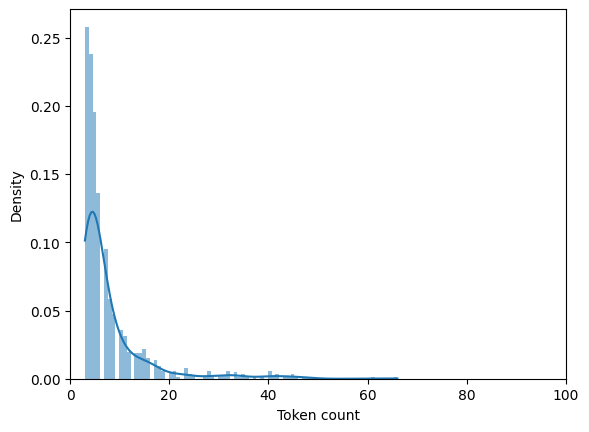

In [ ]:
token_lens = []

for txt in data.content:
  tokens = bert_tokenizer.encode(txt)
  token_lens.append(len(tokens))

sns.histplot(token_lens, kde=True, stat='density', linewidth=0)
plt.xlim([0, 100]);
plt.xlabel('Token count');

In [ ]:
# Dapat dilihat dari grafik diatas, sebagian besar kalimat tampaknya berisi kurang dari 60 token
# Maka, tentukan max_length adalah 60

MAX_LEN = 60

In [ ]:
# Buat fungsi untuk menggabungkan langkah tokenisasi, menambahkan special tokens untuk keseluruhan data sebagai input formatting ke model BERT
def convert_example_to_feature(sentence):
  return bert_tokenizer.encode_plus(
      sentence,
      add_special_tokens = True,
      padding = 'max_length',
      truncation = 'longest_first',
      max_length = MAX_LEN,
      return_attention_mask = True,
      return_token_type_ids=True
    )

In [ ]:
# Membuat fungsi untuk memetakan input hasil input formatting agar sesuai dengan model BERT
def map_example_to_dict(input_ids, attention_masks, token_type_ids, label):
  return {
      "input_ids": input_ids,               # Sebagai token embedding
      "token_type_ids": token_type_ids,     # Sebagai segment embedding
      "attention_mask": attention_masks,    # Sebagai filter informasi mana yang kalkulasi oleh model
  }, label

In [ ]:
def encode(data):
  input_ids_list = []
  token_type_ids_list = []
  attention_mask_list = []
  label_list = []

  for row in data.itertuples(index=False):
    sentence = row.content
    label = row.Label
    bert_input = convert_example_to_feature(sentence)

    input_ids_list.append(bert_input['input_ids'])
    token_type_ids_list.append(bert_input['token_type_ids'])
    attention_mask_list.append(bert_input['attention_mask'])
    label_list.append([label])

  return tf.data.Dataset.from_tensor_slices((input_ids_list, attention_mask_list, token_type_ids_list, label_list)).map(map_example_to_dict)

In [ ]:
# Menentukan nilai hyperparamter untuk fine-tuning
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

In [ ]:
# Melakukan input formatting menggunakan fungsi sebelumnya pada data keseluruhan data
train_encoded = encode(df_train).batch(BATCH_SIZE)
test_encoded = encode(df_test).batch(BATCH_SIZE)
val_encoded = encode(df_val).batch(BATCH_SIZE)

In [ ]:
from transformers import TFBertForSequenceClassification

# Load model
bert_model = TFBertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL, num_labels=3)

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Menentukan optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

# Compile model
bert_model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

In [ ]:
%%time
bert_history = bert_model.fit(train_encoded, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=val_encoded)

Epoch 1/30


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
49/49 [==============================] - 131s 571ms/step - loss: 0.5138 - accuracy: 0.7628 - val_loss: 0.2245 - val_accuracy: 0.9226
Epoch 2/30
49/49 [==============================] - 11s 235ms/step - loss: 0.2322 - accuracy: 0.9222 - val_loss: 0.3486 - val_accuracy: 0.8810
Epoch 3/30
49/49 [==============================] - 11s 227ms/step - loss: 0.1350 - accuracy: 0.9605 - val_loss: 0.2806 - val_accuracy: 0.8988
Epoch 4/30
49/49 [==============================] - 11s 230ms/step - loss: 0.0880 - accuracy: 0.9809 - val_loss: 0.3311 - val_accuracy: 0.9107
Epoch 5/30
49/49 [==============================] - 12s 241ms/step - loss: 0.0518 - accuracy: 0.9885 - val_loss: 0.4189 - val_accuracy: 0.8750
Epoch 6/30
49/49 [==============================] - 12s 236ms/step - loss: 0.0290 - accuracy: 0.9936 - val_loss: 0.4791 - val_accuracy: 0.8869
Epoch 7/30
49/

In [ ]:
# Buat fungsi untuk plotting hasil training
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel('Epochs')
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

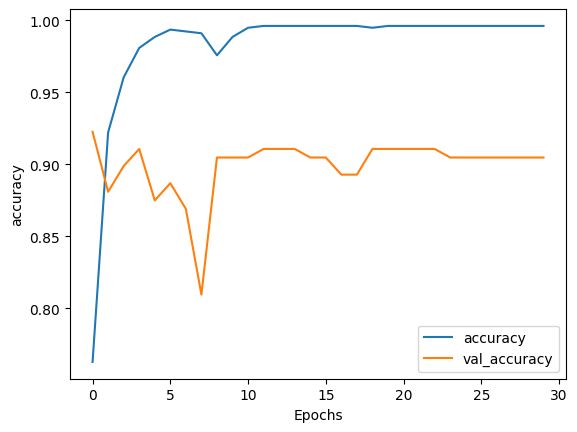

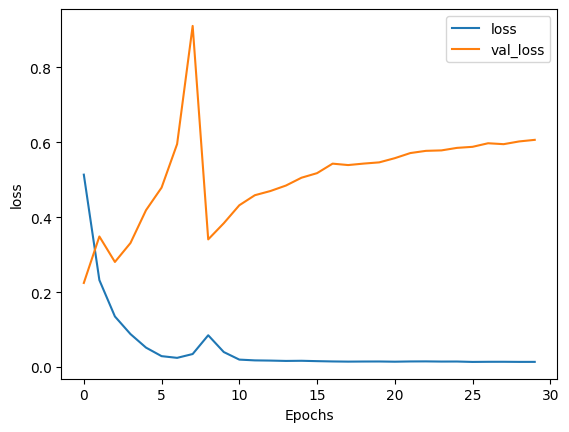

In [ ]:
# menghasilkan plot grafik dari performa model BERT selama proses pelatihan dan validasi
plot_graphs(bert_history, 'accuracy')
plot_graphs(bert_history, 'loss')

In [ ]:
# mencetak informasi tentang performa model BERT pada setiap epoch selama proses pelatihan (training) dan validasi
print('\nEpoch No.  Train Accuracy  Train Loss      Val Accuracy    Val Loss')
for i in range(EPOCHS):
  print('{:8d} {:10f} \t {:10f} \t {:10f} \t {:10f}'.format(i + 1, bert_history.history['accuracy'][i], bert_history.history['loss'][i], bert_history.history['val_accuracy'][i], bert_history.history['val_loss'][i]))


Epoch No.  Train Accuracy  Train Loss      Val Accuracy    Val Loss
       1   0.762755 	   0.513756 	   0.922619 	   0.224517
       2   0.922194 	   0.232170 	   0.880952 	   0.348646
       3   0.960459 	   0.134974 	   0.898810 	   0.280609
       4   0.980867 	   0.087994 	   0.910714 	   0.331133
       5   0.988520 	   0.051802 	   0.875000 	   0.418867
       6   0.993622 	   0.029018 	   0.886905 	   0.479100
       7   0.992347 	   0.024436 	   0.869048 	   0.595498
       8   0.991071 	   0.034671 	   0.809524 	   0.910993
       9   0.975765 	   0.084789 	   0.904762 	   0.340854
      10   0.988520 	   0.040005 	   0.904762 	   0.383935
      11   0.994898 	   0.019769 	   0.904762 	   0.432004
      12   0.996173 	   0.017699 	   0.910714 	   0.458834
      13   0.996173 	   0.017137 	   0.910714 	   0.470021
      14   0.996173 	   0.016234 	   0.910714 	   0.484680
      15   0.996173 	   0.016631 	   0.904762 	   0.505579
      16   0.996173 	   0.015654 	   0.904762 

In [ ]:
# menyimpan model
bert_model.save_weights('/content/drive/MyDrive/FixModel/SastSeabank3016.h5')

In [ ]:
# mengevaluasi performa model BERT pada data uji yang telah diubah menjadi bentuk yang dapat diproses oleh model

score = bert_model.evaluate(test_encoded)

print("Test Accuracy:", score[1])

11/11 [==============================] - 1s 77ms/step - loss: 0.6651 - accuracy: 0.8929
Test Accuracy: 0.8928571343421936


In [ ]:
# melakukan prediksi menggunakan model BERT pada data uji yang telah diubah menjadi bentuk yang dapat diproses oleh model
predicted_raw = bert_model.predict(test_encoded)

11/11 [==============================] - 11s 81ms/step


In [ ]:
y_pred = np.argmax(predicted_raw['logits'], axis=1)
y_true = np.array(df_test['Label'])

In [ ]:
# menghitung akurasi dari model BERT pada data uji dengan membandingkan label kelas yang sebenarnya dengan label kelas yang diprediksi oleh model
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

accuracy_score(y_true, y_pred)

0.8928571428571429

In [ ]:
# menghasilkan matriks confusion dari model BERT pada data uji.
confusion_matrix(y_true, y_pred)

array([[81, 11],
       [ 7, 69]])

In [ ]:
# menghasilkan laporan klasifikasi dari model BERT pada data uji.
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        92
           1       0.86      0.91      0.88        76

    accuracy                           0.89       168
   macro avg       0.89      0.89      0.89       168
weighted avg       0.89      0.89      0.89       168



In [ ]:
sentiment_labels = lb.inverse_transform(data['Label'])
data['Label'] = sentiment_labels

In [ ]:
import seaborn as sns
from wordcloud import WordCloud

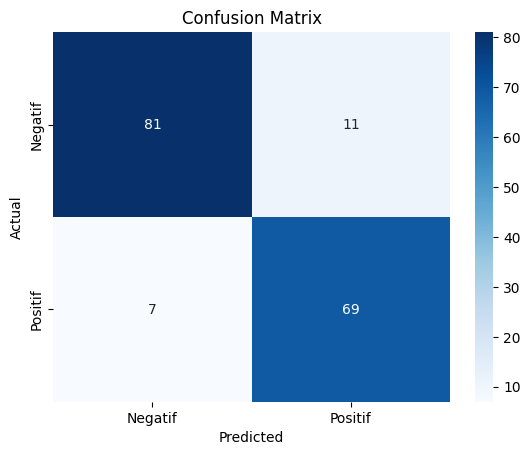

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
data

,content,Label
0,transfer mudah ke mana saja bayar pekerjaan bagus,Positif
1,transaksi lancar,Positif
2,tf bank free memang bagus dan tidak ribet,Positif
3,lmyn kirim akun gratis semoga terus berlanjut,Positif
4,bagus bagus sayang sekali sayang sekali aplika...,Positif
...,...,...
1115,kerusakan,Negatif
1116,fungsional,Negatif
1117,saya harap saya bisa membuat kartu atm,Negatif
1118,ya ampun,Negatif


In [ ]:
data_unlabel = pd.read_excel('/content/drive/MyDrive/DataFix/Label/SastSeabank_DataTestIndo.xlsx')
data_unlabel.head()

,content
0,"hidup itu sederhana, senang rasanya menabung h..."
1,ajukan pinjaman di beranda non-pinjaman
2,cepat dan dapat diandalkan
3,Terima kasih
4,cepat mudah


In [ ]:
# Pra-pemrosesan data yang belum diberi label
data_unlabel['content'] = data_unlabel['content'].apply(text_preprocessing)

In [ ]:
# Ubah data menjadi bentuk yang dapat diproses oleh model BERT
unlabeled_encoded = bert_tokenizer.batch_encode_plus(
    data_unlabel['content'].tolist(),
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_token_type_ids=True
)

In [ ]:
def map_example_to_dict_unlabeled(input_ids, attention_masks, token_type_ids):
    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_masks,
    }

In [ ]:
# Bentuk dataset dari data yang belum diberi label
unlabeled_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': unlabeled_encoded['input_ids'],
        'attention_mask': unlabeled_encoded['attention_mask'],
        'token_type_ids': unlabeled_encoded['token_type_ids']
    },
    tf.zeros((len(data_unlabel),), dtype=tf.int32)  # Labels palsu, semua dengan nilai 0
)).batch(BATCH_SIZE)

In [ ]:
# Lakukan prediksi menggunakan model BERT pada data yang belum diberi label
predictions = bert_model.predict(unlabeled_dataset)

109/109 [==============================] - 19s 75ms/step


In [ ]:
# Ambil label dengan nilai tertinggi pada setiap prediksi
predicted_labels = tf.argmax(predictions.logits, axis=1).numpy()


In [ ]:
# Tambahkan kolom 'Label' pada data yang belum diberi label
data_unlabel['Label'] = predicted_labels

In [ ]:
data_unlabel

,content,Label
0,hidup itu sederhana senang rasanya menabung hi...,1
1,ajukan pinjaman di beranda nonpinjaman,0
2,cepat dan dapat diandalkan,1
3,terima kasih,0
4,cepat mudah,1
...,...,...
1737,sederhana gratis,1
1738,tidak ada masalah yang mudah yang ada adalah m...,1
1739,transaksi cepat dan akurat,1
1740,pelayanan cepat tidak kalah dengan bank bunga ...,1


In [ ]:
data

,content,Label
0,transfer mudah ke mana saja bayar pekerjaan bagus,Positif
1,transaksi lancar,Positif
2,tf bank free memang bagus dan tidak ribet,Positif
3,lmyn kirim akun gratis semoga terus berlanjut,Positif
4,bagus bagus sayang sekali sayang sekali aplika...,Positif
...,...,...
1115,kerusakan,Negatif
1116,fungsional,Negatif
1117,saya harap saya bisa membuat kartu atm,Negatif
1118,ya ampun,Negatif


In [ ]:
sentiment_labels = lb.inverse_transform(data_unlabel['Label'])
data_unlabel['Label'] = sentiment_labels

In [ ]:
data_unlabel

,content,Label
0,hidup itu sederhana senang rasanya menabung hi...,Positif
1,ajukan pinjaman di beranda nonpinjaman,Negatif
2,cepat dan dapat diandalkan,Positif
3,terima kasih,Negatif
4,cepat mudah,Positif
...,...,...
1737,sederhana gratis,Positif
1738,tidak ada masalah yang mudah yang ada adalah m...,Positif
1739,transaksi cepat dan akurat,Positif
1740,pelayanan cepat tidak kalah dengan bank bunga ...,Positif


In [ ]:
# Menggabungkan data train dan data test yang sudah diberi label oleh model
data_combined = pd.concat([data, data_unlabel], axis=0)

In [ ]:
data_combined

,content,Label
0,transfer mudah ke mana saja bayar pekerjaan bagus,Positif
1,transaksi lancar,Positif
2,tf bank free memang bagus dan tidak ribet,Positif
3,lmyn kirim akun gratis semoga terus berlanjut,Positif
4,bagus bagus sayang sekali sayang sekali aplika...,Positif
...,...,...
1737,sederhana gratis,Positif
1738,tidak ada masalah yang mudah yang ada adalah m...,Positif
1739,transaksi cepat dan akurat,Positif
1740,pelayanan cepat tidak kalah dengan bank bunga ...,Positif


In [ ]:
def map_label_to_sentiment(label):
    if label == 'Negatif':
        return 'Negatif'
    else:
        return 'Positif'


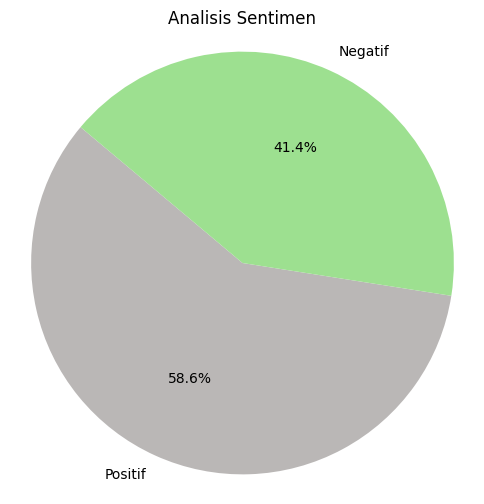

Positif: 1678 data
Negatif: 1184 data


In [ ]:
import matplotlib.pyplot as plt

# Menghitung jumlah data untuk masing-masing sentimen
sentiment_counts = data_combined['Label'].value_counts()

# Membuat diagram pie
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#bab7b6', '#9de090', '#eb5454'])
plt.title('Analisis Sentimen')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Menampilkan keterangan untuk setiap label pada diagram pie
for label, count in sentiment_counts.items():
    print(f"{map_label_to_sentiment(label)}: {count} data")

In [ ]:
# Menyimpan data_combined ke dalam file Excel
output_excel_path = '/content/drive/MyDrive/FixModel/Sast3016Seabankcombinedlabeled.xlsx'
data_combined.to_excel(output_excel_path, index=False)

In [ ]:
# Hitung jumlah data keseluruhan
total_data = len(data_combined)
print("Jumlah Data Keseluruhan:", total_data)

Jumlah Data Keseluruhan: 2862


In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# Kata-kata stopword tambahan
additional_stopwords = []
stop_words = stop_words.union(set(additional_stopwords))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Memisahkan data gabungan menjadi tiga subset berdasarkan label sentimen
data_negative = data_combined[data_combined['Label'] == 'Negatif']
data_positive = data_combined[data_combined['Label'] == 'Positif']

In [ ]:
# Menggabungkan teks dari masing-masing subset menjadi satu teks untuk Wordcloud
negative_texts = " ".join(data_negative['content'].tolist())
positive_texts = " ".join(data_positive['content'].tolist())

In [ ]:
# Fungsi untuk membuat wordcloud dengan stopword removal
def create_wordcloud_with_stopwords(texts, additional_stopwords=None):
    if additional_stopwords is None:
        stop_words = set(stopwords.words('indonesian'))
    else:
        stop_words = set(stopwords.words('indonesian') + additional_stopwords)
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(texts)
    return wordcloud

def plot_word_arrangement(wordcloud, top_n=10):
    sorted_words = sorted(wordcloud.words_.items(), key=lambda x: x[1], reverse=True)
    word_freq = {word: freq for word, freq in sorted_words[:top_n]}

    # Convert word_freq ke pandas Series
    word_freq_series = pd.Series(word_freq)

    # Plot  word arrangement mnggunakan seaborn barplot
    plt.figure(figsize=(10, 5))
    sns.barplot(x=word_freq_series.index, y=word_freq_series.values, palette='viridis')
    plt.title('Word Arrangement')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

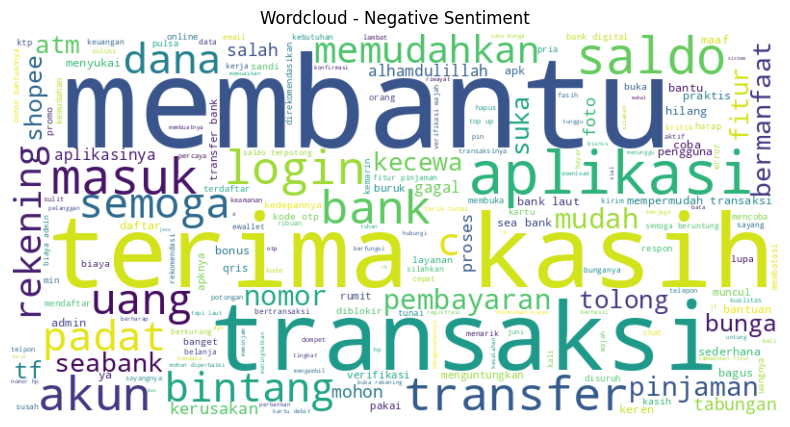

In [ ]:
# Membuat Wordcloud untuk kelas negatif dengan stopword removal tambahan
wordcloud_negative = create_wordcloud_with_stopwords(negative_texts, additional_stopwords)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud - Negative Sentiment')
plt.show()

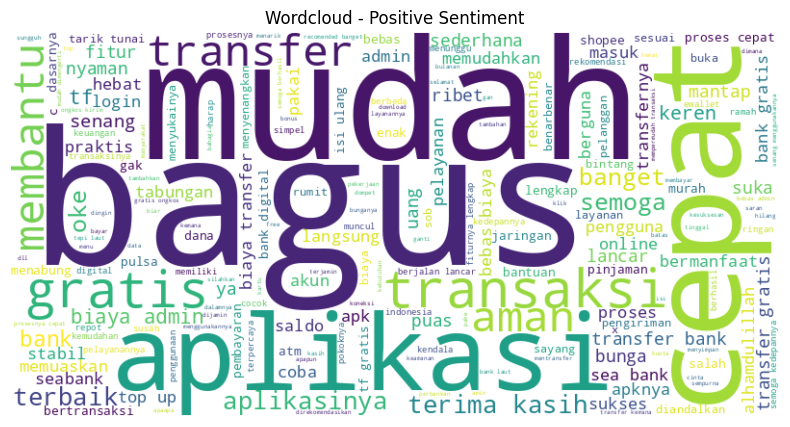

In [ ]:
# Membuat Wordcloud untuk kelas positif dengan stopword removal tambahan
wordcloud_positive = create_wordcloud_with_stopwords(positive_texts, additional_stopwords)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud - Positive Sentiment')
plt.show()


<ipython-input-63-bca8696d1c82>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq_series.index, y=word_freq_series.values, palette='viridis')


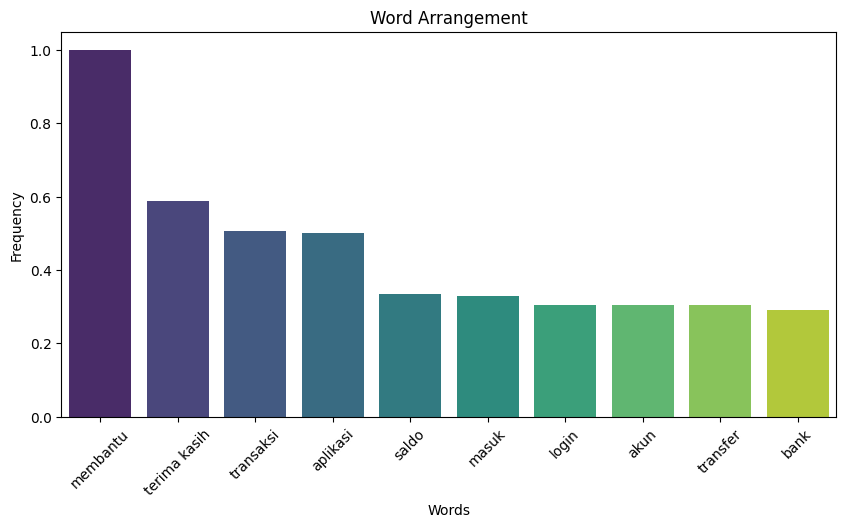

In [ ]:
plot_word_arrangement(wordcloud_negative, top_n=10)

<ipython-input-63-bca8696d1c82>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq_series.index, y=word_freq_series.values, palette='viridis')


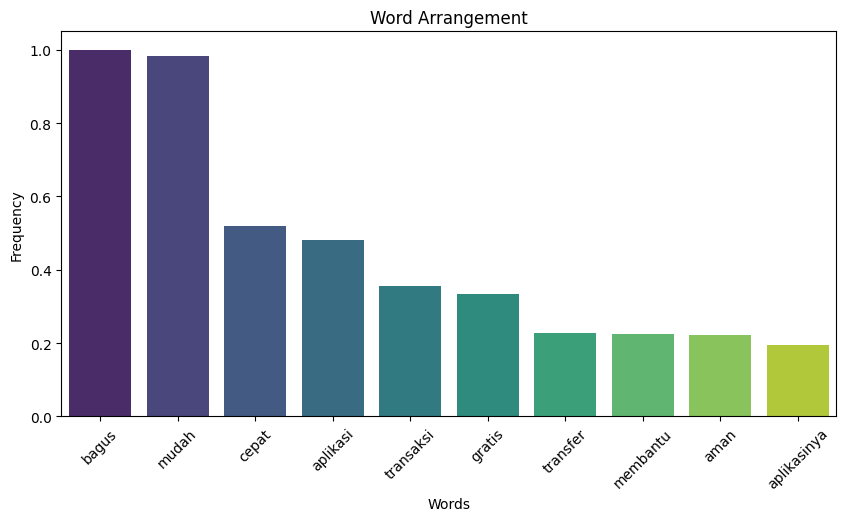

In [ ]:
plot_word_arrangement(wordcloud_positive, top_n=10)

In [ ]:
from transformers import TFBertForSequenceClassification, BertTokenizer

PRE_TRAINED_MODEL = 'indobenchmark/indobert-base-p2'
bert_model = TFBertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL, num_labels=3)

bert_model.load_weights('/content/drive/MyDrive/FixModel/SastSeabank3016.h5')
bert_tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL)


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def text_preprocessing(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[-+]?[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text

def predict_sentiment(text):
    text = text_preprocessing(text)
    encoded_text = bert_tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        padding='max_length',
        truncation='longest_first',
        max_length=60,
        return_attention_mask=True,
        return_token_type_ids=True
    )
    input_ids = np.array([encoded_text['input_ids']])
    token_type_ids = np.array([encoded_text['token_type_ids']])
    attention_mask = np.array([encoded_text['attention_mask']])
    predicted_raw = bert_model.predict({'input_ids': input_ids, 'token_type_ids': token_type_ids, 'attention_mask': attention_mask})
    predicted_label = np.argmax(predicted_raw.logits, axis=1)
    sentiment_label = map_label_to_sentiment(predicted_label[0])
    return sentiment_label

In [ ]:
def map_label_to_sentiment(label):
    if label == 0:
        return 'Negatif'
    elif label == 1:
        return 'Positif'
    else:
        return None  # Mengabaikan label selain 0 dan 1


In [ ]:
# Contoh teks yang ingin diuji
input_text = "aplikasi yang sangat bagus good"

# Lakukan prediksi sentimen pada teks
predicted_sentiment = predict_sentiment(input_text)

# Cetak hasil prediksi
print("Input Text:", input_text)
print("Predicted Sentiment:", predicted_sentiment)

1/1 [==============================] - 11s 11s/step
Input Text: aplikasi yang sangat bagus good
Predicted Sentiment: Positif


In [ ]:
# Contoh teks yang ingin diuji
input_text = "Bagus sekali aplikasinya"

# Lakukan prediksi sentimen pada teks
predicted_sentiment = predict_sentiment(input_text)

# Cetak hasil prediksi
print("Input Text:", input_text)
print("Predicted Sentiment:", predicted_sentiment)

1/1 [==============================] - 0s 46ms/step
Input Text: Bagus sekali aplikasinya
Predicted Sentiment: Positif


In [ ]:
# Contoh teks yang ingin diuji
input_text = "Aplikasi jelek banget"

# Lakukan prediksi sentimen pada teks
predicted_sentiment = predict_sentiment(input_text)

# Cetak hasil prediksi
print("Input Text:", input_text)
print("Predicted Sentiment:", predicted_sentiment)

1/1 [==============================] - 0s 49ms/step
Input Text: Aplikasi jelek banget
Predicted Sentiment: Positif
